In [11]:
!pip install -U sentence-transformers

In [12]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Load the specific model required by the task
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
sentences = [
    # Cricket
    "Powerplay overs allow the batting side to take advantage of fielding restrictions.",
    "A perfect yorker can dismantle the stumps of even the best hitters.",
    "The umpire signaled a wide ball after it passed outside the crease.",
    # Cooking
    "Simmer the sauce on low heat until it reaches a thick consistency.",
    "Using fresh basil and olive oil elevates the flavor of the pasta.",
    "Fold the flour into the batter gently to avoid deflating the incorporated air.",
    "Whisk the egg whites until they form stiff, glossy peaks.",
    # Cybersecurity
    "Always use a VPN when accessing sensitive data on public Wi-Fi.",
    "A firewall acts as a barrier between a trusted and untrusted network.",
    "Strong end-to-end encryption ensures that messages remain private during transmission."
]

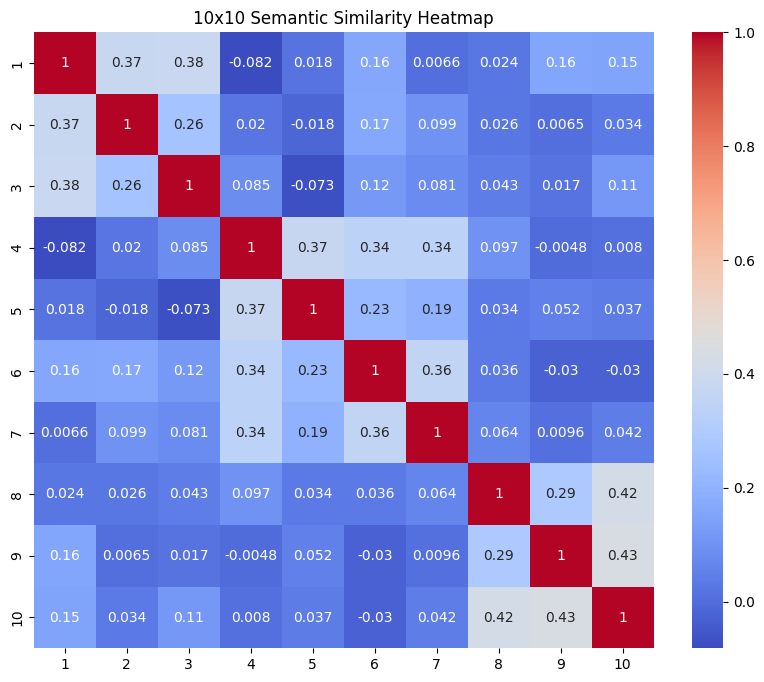

In [14]:
# Below logic is for Generating embeddings
embeddings = model.encode(sentences, convert_to_tensor=True)

# Below code is for computing the 10x10 Cosine Similarity Matrix
cosine_scores = util.cos_sim(embeddings, embeddings)

# Below code is for displaying as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores.cpu().numpy(), annot=True, cmap='coolwarm',
            xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.title("10x10 Semantic Similarity Heatmap")
plt.show()

In [15]:
query_sentence = "The bowler took three wickets in one over"
query_embedding = model.encode(query_sentence, convert_to_tensor=True)

# Find top 2 matches
hits = util.semantic_search(query_embedding, embeddings, top_k=2)

print(f"Query: {query_sentence}\n")
for hit in hits[0]:
    print(f"Match: \"{sentences[hit['corpus_id']]}\"")
    print(f"Similarity Score: {hit['score']:.4f}\n")

Query: The bowler took three wickets in one over

Match: "The umpire signaled a wide ball after it passed outside the crease."
Similarity Score: 0.4141

Match: "Powerplay overs allow the batting side to take advantage of fielding restrictions."
Similarity Score: 0.3999

